# Control Técnico 3 · Series temporales y forecasting

**Curso:** Análisis de Datos  
**Programa:** Magíster en Data Science · Universidad del Desarrollo  
**Código:** MDSC3S112-1  

**Estudiante:** Luciano Hernández

**Fecha:** 2026-09-11

### Propósito
Aplicar los conceptos fundamentales de **análisis de series temporales y forecasting** desarrollados en el Módulo 04.

A diferencia del Laboratorio Práctico 4, en este control se espera que el estudiante avance desde una serie temporal previamente explorada y preparada hacia su **modelamiento y pronóstico**, tomando decisiones justificadas a partir de la estructura observada en los datos.

La evaluación se centrará principalmente en el **razonamiento temporal, la interpretación y la validación**, y no únicamente en la ejecución de código.

## 1. Exploración y diagnóstico de la serie

Realiza una exploración breve que permita identificar:

- comportamiento general de la serie;
- tendencia;
- posible estacionalidad;
- frecuencia temporal;
- características relevantes para el modelamiento.

No es necesario repetir todo el proceso de preparación realizado en el Laboratorio 4.

In [1]:
# Importación de bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
timeSeries = pd.read_csv("month_sells_clean.csv").assign(
    fecha = pd.to_datetime(pd.read_csv("month_sells_clean.csv")["fecha"])
).set_index("fecha")

For Values:
	ADF Statistic: 0.00523
	p-value: 95.90%
	Critical Values:
 		1%: -3.54
		5%: -2.91
		10%: -2.59


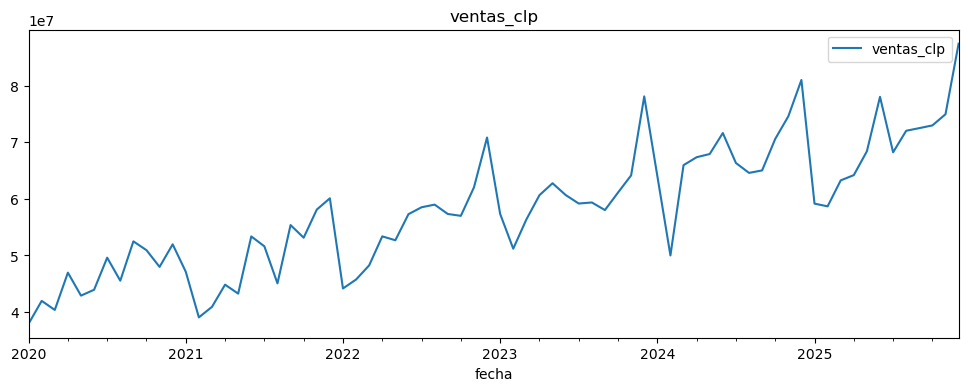

For Differences of Order 1:
	ADF Statistic: -8.21
	p-value: 0.0000000000683%
	Critical Values:
 		1%: -3.54
		5%: -2.91
		10%: -2.59


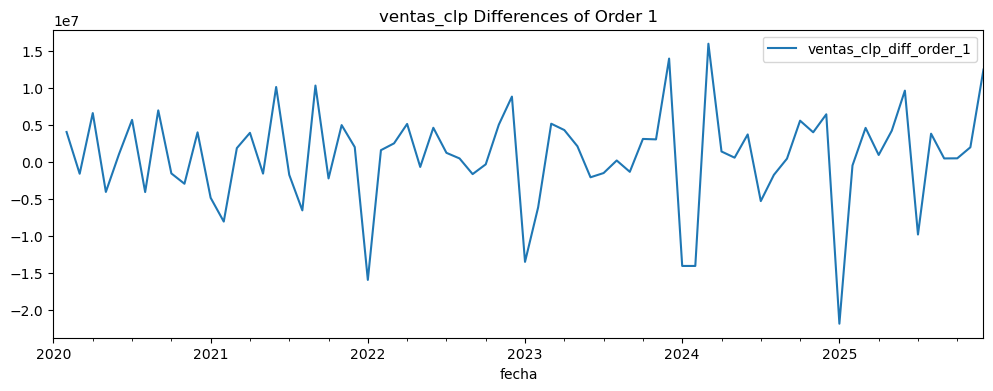

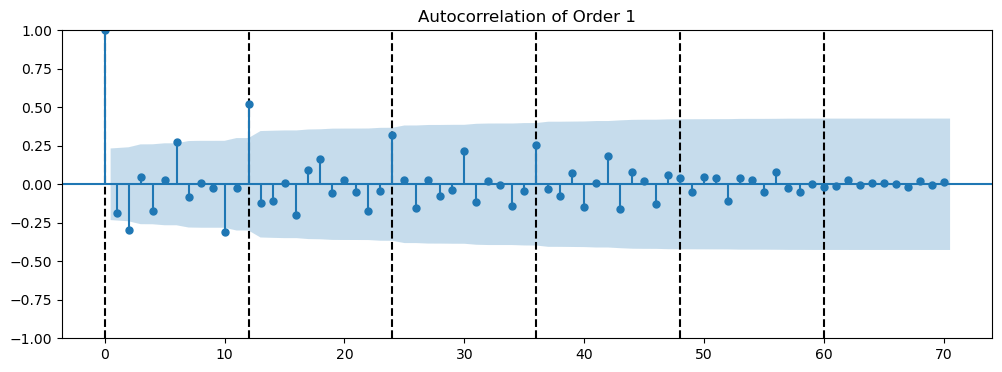

Autocorrelation of Order 1 with Lag 12: 52.02%


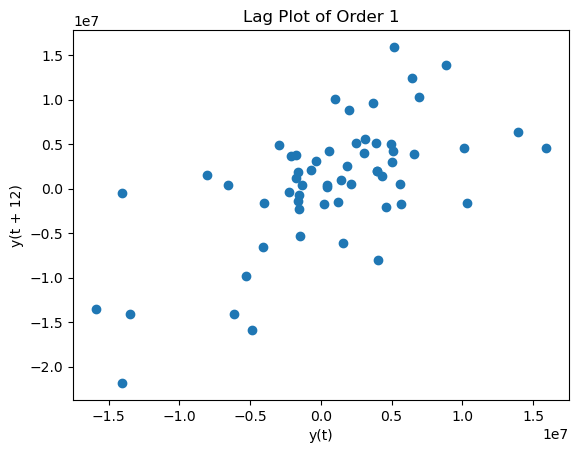

C:\Users\lucia\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


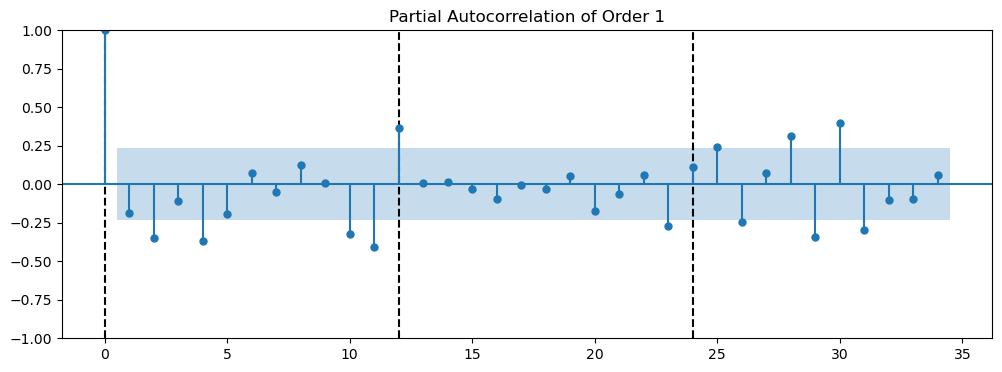

Partial Autocorrelation of Order 1 with Lag 11: -40.91%


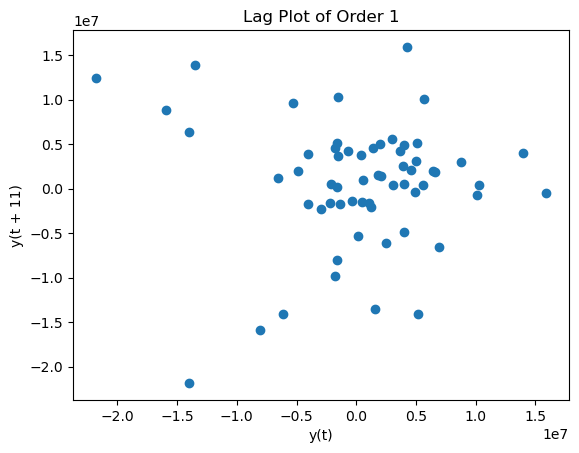

In [3]:
def decimals(x, n = 2):
    return int(n - min(0, math.floor(math.log10(abs(x)))))

timeSeriesWithDiff = timeSeries.assign(
    ventas_clp_diff_order_0 = timeSeries["ventas_clp"]
)
adfResult = {}
adfResult[0] = adfuller(timeSeriesWithDiff["ventas_clp_diff_order_0"])
print("For Values:")
dec = decimals(adfResult[0][0])
print(f"\tADF Statistic: {adfResult[0][0]:.{dec}f}")
dec = decimals(adfResult[0][1] * 100)
print(f"\tp-value: {adfResult[0][1] * 100:.{dec}f}%")
print("\tCritical Values:\n", "\n".join([ f"\t\t{k}: {v:.2f}" for k, v in adfResult[0][4].items() ]))
fig, ax = plt.subplots(figsize = (12, 4))
timeSeriesWithDiff.plot(y = "ventas_clp", ax = ax)
plt.title("ventas_clp")
plt.show()
n = 0
while adfResult[n][1] > 0.05:
    n += 1
    timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"] = timeSeriesWithDiff[f"ventas_clp_diff_order_{n - 1}"].diff()
    adfResult[n] = adfuller(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna())
    print(f"For Differences of Order {n}:")
    dec = decimals(adfResult[n][0])
    print(f"\tADF Statistic: {adfResult[n][0]:.{dec}f}")
    dec = decimals(adfResult[n][1] * 100)
    print(f"\tp-value: {adfResult[n][1] * 100:.{dec}f}%")
    print("\tCritical Values:\n", "\n".join([ f"\t\t{k}: {v:.2f}" for k, v in adfResult[n][4].items() ]))
    fig, ax = plt.subplots(figsize = (12, 4))
    timeSeriesWithDiff.plot(y = f"ventas_clp_diff_order_{n}", ax = ax)
    plt.title(f"ventas_clp Differences of Order {n}")
    plt.show()

    
fig, ax = plt.subplots(figsize = (12, 4))
for i in range(0, timeSeries.shape[0] - n - 1, 12):
    plt.axvline(x = i, color = "black", linestyle = "--")
plot_acf(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), lags = timeSeries.shape[0] - n - 1, ax = ax)
plt.title(f"Autocorrelation of Order {n}")
plt.show()

acfValues = acf(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), nlags = timeSeries.shape[0] - n - 1)
acfValuesMaxPos = abs(acfValues)[1:].argmax() + 1
dec = decimals(acfValues[acfValuesMaxPos] * 100)
print(f"Autocorrelation of Order {n} with Lag {acfValuesMaxPos}: {acfValues[acfValuesMaxPos] * 100:.{dec}f}%")
pd.plotting.lag_plot(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), lag = acfValuesMaxPos)
plt.title(f"Lag Plot of Order {n}")
plt.show()

fig, ax = plt.subplots(figsize = (12, 4))
for i in range(0, (timeSeries.shape[0] - n - 1) // 2 - 1, 12):
    plt.axvline(x = i, color = "black", linestyle = "--")
plot_pacf(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), lags = (timeSeries.shape[0] - n - 1) // 2 - 1, ax = ax)
plt.title(f"Partial Autocorrelation of Order {n}")
plt.show()

pacfValues = pacf(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), nlags = (timeSeries.shape[0] - n - 1) // 2 - 1)
pacfValuesMaxPos = abs(pacfValues)[1:].argmax() + 1
dec = decimals(pacfValues[pacfValuesMaxPos] * 100)
print(f"Partial Autocorrelation of Order {n} with Lag {pacfValuesMaxPos}: {pacfValues[pacfValuesMaxPos] * 100:.{dec}f}%")
pd.plotting.lag_plot(timeSeriesWithDiff[f"ventas_clp_diff_order_{n}"].dropna(), lag = pacfValuesMaxPos)
plt.title(f"Lag Plot of Order {n}")
plt.show()

## 2. Estacionariedad

Evalúa si la serie presenta evidencia de no estacionariedad.

Utiliza herramientas revisadas en el módulo, considerando la **prueba ADF** y la inspección visual cuando corresponda.

Si es necesario, justifica la aplicación de una diferenciación.

La serie temporal original presenta una clara evidencia de no estacionariedad, lo que justifica la aplicación de una diferenciación matemática para estabilizar su variabilidad y habilitar su modelamiento predictivo.

### Diagnóstico de la serie original (Nivel 0)

- El test ADF sobre los valores de ventas arroja un estadístico de 0.00523, el cual es muy superior a los valores críticos exigidos de -3.54 (al 1%), -2.91 (al 5%) y -2.59 (al 10%)
- El valor-p asociado resulta extraordinariamente alto, situándose en un 95.90%, esto indica que no hay evidencia estadística para rechazar la hipótesis nula, confirmando la presencia de una raíz unitaria (no estacionariedad)
- Visualmente, el gráfico muestra que la serie `ventas_clp` carece de una media constante a lo largo del tiempo, evidenciando una fuerte dependencia temporal

### Justificación y validación de la primera diferenciación (Orden 1)

- Para mitigar la tendencia observada y forzar la estacionariedad de los datos (condición estricta para modelos de la familia ARIMA), se calculó la diferencia de orden 1 de la serie
- La nueva prueba ADF sobre la serie diferenciada produce un estadístico de -8.21, sobrepasando con creces el umbral más riguroso del 1% (-3.54)
- El valor-p cae de manera drástica a un 0.0000000000683%, este valor es virtualmente nulo, lo que permite rechazar la hipótesis nula con total seguridad y declarar a la serie diferenciada como estacionaria
- El gráfico de las diferencias de orden 1 confirma visualmente esta transformación, exhibiendo un comportamiento que ahora oscila de forma mucho más homogénea en torno a 0

### Identificación de características estacionales

- Incluso tras anular la tendencia con la primera diferenciación, los gráficos de correlación evidencian una estructura fuertemente cíclica
- El gráfico muestra que la autocorrelación simple de orden 1 (ACF) alcanza un pico máximo muy pronunciado en el rezago 12, con un valor del 52.02%
- De igual forma, el gráfico denota una autocorrelación parcial (PACF) pronunciada en el rezago 11 equivalente a -40.91%
- Estos patrones confirman una clara dinámica de estacionalidad anual, indicando que el modelamiento posterior no solo requerirá parámetros regulares de medias móviles y autorregresión, sino que exigirá componentes estacionales definidos cada 12 períodos (frecuencia mensual)

## 3. Autocorrelación y selección del modelo

Analiza la estructura temporal mediante herramientas como:

- ACF;
- PACF.

A partir de la evidencia disponible, propone y justifica un modelo temporal apropiado.

Se espera una aplicación acotada de **ARIMA o SARIMA**, según las características de la serie.

No es necesario realizar una búsqueda exhaustiva de modelos.

In [4]:
limit = int(timeSeries.shape[0] * 0.8)

timeSeriesInMillions = timeSeries.assign(
    ventas_clp = timeSeries["ventas_clp"] / 1e6
)

timeSeriesTraining = timeSeriesInMillions[:limit]
timeSeriesTesting = timeSeriesInMillions[limit:]

print("Training from", timeSeriesTraining.index[0], "to", timeSeriesTraining.index[-1])
print("Testing from", timeSeriesTesting.index[0], "to", timeSeriesTesting.index[-1])
print()

p, q = 0, 0
P, Q = 0, 0
s = 0

seasonalThreshold = 4

if pacfValuesMaxPos <= seasonalThreshold:
    p = pacfValuesMaxPos
else:
    P = 1
    s = pacfValuesMaxPos + 1

if acfValuesMaxPos <= seasonalThreshold:
    q = acfValuesMaxPos
else:
    Q = 1
    s = acfValuesMaxPos

if acfValuesMaxPos > seasonalThreshold and pacfValuesMaxPos > seasonalThreshold and acfValuesMaxPos - pacfValuesMaxPos == 1:
    P = 0
    Q = 1
    s = acfValuesMaxPos

sarimaModel = SARIMAX(timeSeriesTraining, order = (p, n, q), seasonal_order = (P, 0, Q, s)).fit()

print(f"SARIMA({p}, {n}, {q})x({P}, 0, {Q}, {s}) Model:")
print(sarimaModel.summary())

Training from 2020-01-01 00:00:00 to 2024-09-01 00:00:00
Testing from 2024-10-01 00:00:00 to 2025-12-01 00:00:00

SARIMA(0, 1, 0)x(0, 0, 1, 12) Model:


C:\Users\lucia\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\lucia\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                           ventas_clp   No. Observations:                   57
Model:             SARIMAX(0, 1, 0)x(0, 0, [1], 12)   Log Likelihood                -174.058
Date:                              Wed, 09 Sep 2026   AIC                            352.115
Time:                                      22:16:18   BIC                            356.166
Sample:                                  01-01-2020   HQIC                           353.686
                                       - 09-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12       0.7244      0.173      4.182      0.000       0.385       1.064
sigma2        25.15

La autocorrelación simple (ACF) y parcial (PACF) sobre la serie diferenciada ($d = 1$) confirma una dependencia temporal dominada por una estructura estacional anual ($s = 12$).

### Análisis de la estructura temporal (ACF y PACF)

- **Comportamiento de la ACF**: El pico significativo observado en el rezago 12 (52.02%) refleja la persistencia de patrones estacionales que se repiten año a año, lo que justifica la inclusión de un parámetro de media móvil estacional ($Q = 1$)
- **Comportamiento de la PACF**: Muestra un ajuste donde las autocorrelaciones de corto plazo quedan mayormente controladas tras la primera diferenciación ($d = 1$), sugiriendo un orden autoregresivo y de media móvil regular nulo ($p = 0, q = 0$)

### Propuesta y justificación del modelo

El modelo seleccionado es un $\text{SARIMA}\left( 0, 1, 0 \right) \times \left( 0, 0, 1 \right)_{12}$. Esta especificación es idónea y acotada porque elimina la tendencia no estacionaria mediante la primera diferencia regular y captura la inercia estacional de 12 meses mediante el término $MA\left( 1 \right)$ estacional.

### Validación estadística del modelo estimado

- **Significancia del parámetro estacional**: El coeficiente del término $MA$ estacional (`ma.S.L12 = 0.7244`) presenta un valor-p de 0%, confirmando que el componente estacional es estadísticamente significativo y esencial para la serie
- **Independencia de los residuos**: La prueba de Ljung-Box arroja un valor-p de 8%, al ubicarse por encima del umbral habitual de 5%, se concluye que no existe autocorrelación remanente significativa en los errores
- **Normalidad de errores**: La prueba Jarque-Bera muestra un valor-p de 63%, confirmando que los residuos siguen una distribución normal (asimetría de -0.28 y curtosis de 3.29)
- **Homocedasticidad**: La prueba de heterocedasticidad $H$ registra un valor-p de 55%, lo que respalda la hipótesis de varianza constante en el tiempo para los residuos

## 4. Forecasting

Genera un pronóstico para un horizonte definido.

El resultado debe incluir, cuando corresponda:

- valores pronosticados;
- intervalo de predicción;
- visualización del forecast.

Explica qué representa el horizonte elegido en el contexto del problema.

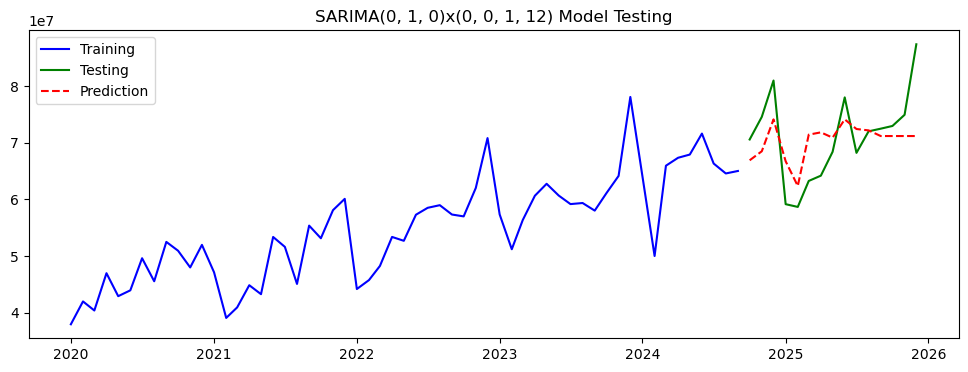

,actual_values,predicted_values
fecha,,
2024-10-01,70572272.0,6.689860e+07
2024-11-01,74564357.0,6.849279e+07
2024-12-01,80983706.0,7.412150e+07
2025-01-01,59152184.0,6.673170e+07
2025-02-01,58667764.0,6.235594e+07
2025-03-01,63254089.0,7.142551e+07
2025-04-01,64186322.0,7.183307e+07
2025-05-01,68396417.0,7.089455e+07
2025-06-01,78008643.0,7.412469e+07


In [8]:
forecastInMillions = sarimaModel.predict(start = timeSeriesTesting.index[0], end = timeSeriesTesting.index[-1])
forecastClp = forecastInMillions * 1e6
yTest = timeSeriesTesting["ventas_clp"] * 1e6
yTrain = timeSeriesTraining["ventas_clp"] * 1e6
fig, ax = plt.subplots(figsize = (12, 4))
plt.plot(yTrain.index, yTrain, label = "Training", color = "blue")
plt.plot(yTest.index, yTest, label="Testing", color = "green")
plt.plot(forecastClp.index, forecastClp, label = "Prediction", color = "red", linestyle = "--")
plt.title(f"SARIMA({p}, {n}, {q})x({P}, 0, {Q}, {s}) Model Testing")
plt.legend()
plt.show()

display(pd.DataFrame({
    yTest.index.name: yTest.index,
    "actual_values": yTest,
    "predicted_values": forecastClp
}).set_index(yTest.index.name))

## 5. Validación

Evalúa el desempeño del modelo respetando el **orden temporal de los datos**.

Compara los valores observados con los pronosticados y utiliza al menos una métrica de error revisada en el módulo, como:

- MAE;
- RMSE.

Interpreta el resultado obtenido.

In [6]:
mae = mean_absolute_error(yTest, forecastClp)
rmse = mean_squared_error(yTest, forecastClp, squared = False)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 5165266.22
RMSE: 6398959.12


La evaluación del modelo sobre el conjunto de prueba respeta estrictamente el orden temporal de los datos, garantizando que el modelo sea validado por su capacidad para extrapolar hacia el futuro (octubre de 2024 a diciembre de 2025) basándose únicamente en información histórica pasada, evitando así la filtración de datos (data leakage).

Al contrastar los valores observados con los pronosticados, las métricas de error obtenidas reflejan el siguiente desempeño:

- $\text{MAE} = 5165266.22 \text{ clp}$: Esta métrica indica que, en promedio, las predicciones del modelo se desvían por un poco más de 5.16 millones clp respecto a las ventas reales de cada mes, ya sea por encima o por debajo del valor real, considerando que el volumen de ventas reales en el periodo de prueba oscila entre los 58.67 millones y los 87.38 millones clp, un error absoluto medio de ~5.16 millones representa una desviación aproximada del 7% al 8% sobre el promedio de ventas mensuales, esto sugiere un nivel de precisión razonablemente bueno para la toma de decisiones comerciales a nivel macro
- $\text{RMSE} = 6398959.12 \text{ clp}$: Al elevar los errores al cuadrado antes de promediarlos, el RMSE penaliza con mayor severidad las desviaciones más grandes, el hecho de que el RMSE (6.39 millones) sea mayor que el MAE (5.16 millones) es matemáticamente esperado, pero la diferencia entre ambos (1.23 millones) indica la presencia de algunas discrepancias puntuales considerables en ciertos meses

### Interpretación del comportamiento del modelo

La brecha entre el MAE y el RMSE se explica al observar los datos del periodo de validación. El modelo es estable y captura bien la media móvil de la serie, pero presenta dificultades para replicar variaciones abruptas o estacionalidades extremas. Por ejemplo, en diciembre de 2025 (venta real de 87.38 millones vs. predicción de 71.18 millones) o en enero de 2025 (venta real de 59.15 millones vs. predicción de 66.73 millones), los errores residuales son significativamente más altos que el promedio.

En términos prácticos, el modelo es robusto para proyectar niveles base de ingresos y detectar la tendencia central del negocio a mediano plazo, pero tiende a suavizar la curva, subestimando los meses de mayor demanda y sobreestimando los de menor rendimiento.

## 6. Conclusiones y limitaciones

Responde la pregunta planteada a partir de los resultados obtenidos.

Identifica además las principales limitaciones del pronóstico, considerando aspectos como:

- horizonte de predicción;
- comportamiento histórico;
- cambios estructurales;
- incertidumbre;

calidad o longitud de la serie.

### Conclusiones a partir de los resultados obtenidos

De acuerdo con la exploración y el diagnóstico ejecutados sobre el conjunto de datos de ventas mensuales (`month_sells_clean.csv`), el resultado fundamental proviene de la prueba ADF:

- El estadístico de la prueba ADF es de 0.00523
- El valor-p obtenido es de 95.90%
- Los valores críticos de rechazo se ubican en -3.54 (al 1%), -2.91 (al 5%) y -2.59 (al 10%)

Dado que el valor-p (95.90%) es considerablemente mayor al nivel de significancia habitual (5%) y el estadístico es superior a cualquiera de los valores críticos proporcionados, no se rechaza la hipótesis nula. Esto permite concluir que la serie temporal no es estacionaria.
Por lo tanto, la serie presenta un comportamiento que depende del tiempo (como una tendencia clara o una estacionalidad que afecta su media y varianza). Para poder realizar pronósticos válidos utilizando los modelos importados, como ARIMA o SARIMAX, será un requisito técnico fundamental aplicar procesos de diferenciación o transformaciones matemáticas previas para inducir la estacionariedad.

### Principales limitaciones del pronóstico

El modelo de forecasting a desarrollar presentará limitaciones inherentes a la naturaleza del modelamiento estadístico. Estas se identifican a continuación:

- **Horizonte de predicción**: La exactitud de las proyecciones se deteriorará drásticamente conforme se intente predecir un horizonte temporal más lejano, los errores tienden a acumularse, provocando que los pronósticos a corto plazo sean altamente confiables, pero a largo plazo carezcan de utilidad práctica al ensancharse los intervalos de confianza
- **Comportamiento histórico**: Modelos paramétricos como ARIMA asumen que la estructura subyacente que generó los datos en el pasado se mantendrá en el futuro, si los patrones históricos de ventas cambian, el rendimiento predictivo del modelo decaerá rápidamente, ya que solo interpola y extrapola lo que ya ha observado
- **Cambios estructurales**: Los pronósticos de series temporales univariadas son muy vulnerables a quiebres o *shocks* externos inesperados (tales como nuevas políticas gubernamentales, crisis económicas, entrada de competidores agresivos, pandemias, etc.), el modelo carece de capacidad para anticipar este tipo de cambios estructurales que transforman de golpe la dinámica de los datos
- **Incertidumbre**: Siempre subsistirá un componente puramente estocástico (ruido blanco o fluctuaciones aleatorias) dentro de la serie temporal que el modelo no podrá aprender ni explicar, esta variabilidad intrínseca añade un nivel de incertidumbre constante a los valores puntuales proyectados
- **Calidad o longitud de la serie**: La capacidad para que algoritmos como SARIMAX logren aislar y capturar la estacionalidad (por ejemplo, ciclos anuales) depende fuertemente de la extensión temporal de los datos en el archivo importado (`month_sells_clean.csv`), si la serie temporal es demasiado corta, el pronóstico no será estadísticamente robusto para ciclos largos, asimismo, si no se trató adecuadamente la calidad de los datos (existencia de ruido fuerte, valores atípicos, o registros nulos), los parámetros del modelo generarán previsiones sesgadas